# Multi-metric exploration of non-homomorphism

**Status:** EXPLORATORY

We compute six information-theoretic metrics on the expanded game library and ask which metrics agree and which structural properties predict each metric.

**Metrics:** KL divergence (joint vs independent); transfer entropy; effective information; Markov entropy rate; Φ₂.₅-style synergistic MI; causal emergence.

**Meta-hypothesis:** Similar metrics cluster (Spearman ρ > 0.6 within cluster).

**Survive criterion:** Either ≥2 metrics cluster and correlate with structure, or at least one metric has ρ > 0.5 with a property (bootstrap-backed).

**Round C-revised.** Original Round C used Williams–Beer PID only; inconclusive effects plus `dit`/NumPy 2.x blocked BROJA/PPID.

Cumulative-sum metrics sample perturbations from `trajectories.DEFAULT_TRAJECTORY_COMPONENT_NAMES` (default: `{ZERO, ONE, NEG_ONE, STAR}` — ↑/↓ omitted because repeated sums blow up). Transfer entropy / marginal Markov chains use **8** cumulative steps; the compound-sum branch in Markov uses **5** steps (`metrics_markov.compound_trajectory_steps`) because `outcome(add(cur1, cur2))` dominates runtime.

**Why this notebook can pin all CPUs for a long time:** for each unordered pair you run several metrics; `effective_information` and `causal_emergence` iterate over **all ordered pairs of perturbations** from the library (size \(N^2\) in the number of games). With ~171 pairs and `n_jobs=-1`, joblib saturates every core — that is expected for this workload, not a hang. For interactive runs lower **`n_jobs`**, set **`pair_limit`**, or set **`include_heavy_metrics = False`** (skips EI + causal emergence).


In [1]:
import os

random_seed = 42
output_dir = "data"
figures_dir = "figures"
# Default: use half the logical CPUs (capped) so the machine stays responsive.
# Papermill: `-p n_jobs -1` for a full fan-out overnight run.
n_jobs = max(1, min(8, (os.cpu_count() or 4) // 2))
# None = all pairs; set e.g. `40` for a fast smoke run.
pair_limit = None
# False skips effective_information + causal_emergence (largest cost per pair).
include_heavy_metrics = True

In [2]:
# Parameters
pair_limit = 40
include_heavy_metrics = "false"
n_jobs = 8


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from conway_foundations.utils.parallel import detect_compute_backend, parallel_map

np.random.seed(random_seed)
output_dir = Path(output_dir)
figures_dir = Path(figures_dir)
output_dir.mkdir(exist_ok=True, parents=True)
figures_dir.mkdir(exist_ok=True, parents=True)

print("Compute backend:", detect_compute_backend())

Compute backend: {'cpu_count': 12, 'cpu_count_physical': 12, 'cuda_available': False, 'mps_available': False, 'accelerate_blas': True}


## Setup


In [4]:
from conway_foundations.games.arithmetic import clear_arithmetic_cache
from conway_foundations.games.library import CANONICAL_LIBRARY_EXPANDED
from conway_foundations.games.outcome import clear_outcome_cache
from conway_foundations.games.properties import all_properties
from conway_foundations.synergy import METRIC_REGISTRY
from conway_foundations.synergy.trajectories import (
    generate_independent_perturbations,
    generate_trajectory,
)

library = CANONICAL_LIBRARY_EXPANDED
n_lib = len(library)
print(f"Library size: {n_lib}")
print(f"Pairs: {n_lib * (n_lib - 1) // 2}")
print(f"Metrics registered: {list(METRIC_REGISTRY.keys())}")

Library size: 19
Pairs: 171
Metrics registered: ['effective_information', 'causal_emergence', 'kl_divergence', 'markov_entropy_rate', 'phi_approx', 'transfer_entropy']


In [5]:
trajectory_t20 = generate_trajectory(library, length=20, seed=random_seed)
independent_perturbations = generate_independent_perturbations(library)

print(f"Trajectory length: {len(trajectory_t20)} (sampled from low-depth pool)")
print(f"Independent perturbations: {len(independent_perturbations)}")

Trajectory length: 20 (sampled from low-depth pool)
Independent perturbations: 19


In [6]:
pairs = []
for i, (n1, g1) in enumerate(library):
    for j, (n2, g2) in enumerate(library):
        if i < j:
            pairs.append((n1, n2, g1, g2))
if pair_limit is not None:
    pairs = pairs[: int(pair_limit)]
print(f"Total pairs: {len(pairs)} (pair_limit={pair_limit!r})")

Total pairs: 40 (pair_limit=40)


In [7]:
METRICS_TRAJ = ["transfer_entropy", "markov_entropy_rate"]
METRICS_INDEP = ["kl_divergence", "phi_approx"]
if include_heavy_metrics:
    METRICS_INDEP = [
        "kl_divergence",
        "effective_information",
        "phi_approx",
        "causal_emergence",
    ]


def compute_all_metrics_for_pair(pair):
    n1, n2, g1, g2 = pair

    metrics_traj = METRICS_TRAJ
    metrics_indep = METRICS_INDEP

    result = {"pair": f"{n1}+{n2}", "g1": n1, "g2": n2}

    p1 = all_properties(g1)
    p2 = all_properties(g2)
    o1, o2 = str(p1["outcome"]), str(p2["outcome"])
    base_class = o1 if o1 == o2 else "mixed"

    result["base_class"] = base_class
    result["avg_depth"] = (int(p1["depth"]) + int(p2["depth"])) / 2
    result["avg_num_options"] = (int(p1["num_options"]) + int(p2["num_options"])) / 2
    result["avg_fuzzy_count"] = (int(p1["fuzzy_count"]) + int(p2["fuzzy_count"])) / 2
    result["avg_canonical_size"] = (int(p1["canonical_size"]) + int(p2["canonical_size"])) / 2

    clear_outcome_cache()
    clear_arithmetic_cache()

    for metric_name in metrics_traj:
        metric = METRIC_REGISTRY[metric_name]
        try:
            res = metric(g1, g2, trajectory_t20)
            for k, v in res.items():
                if k != "sample_size":
                    result[f"{metric_name}__{k}"] = v
        except Exception as e:
            result[f"{metric_name}__error"] = type(e).__name__

    clear_outcome_cache()
    clear_arithmetic_cache()

    for metric_name in metrics_indep:
        metric = METRIC_REGISTRY[metric_name]
        try:
            res = metric(g1, g2, independent_perturbations)
            for k, v in res.items():
                if k != "sample_size":
                    result[f"{metric_name}__{k}"] = v
        except Exception as e:
            result[f"{metric_name}__error"] = type(e).__name__

    return result


print(
    f"parallel_map: n_jobs={n_jobs}, include_heavy_metrics={include_heavy_metrics}",
)
results = parallel_map(compute_all_metrics_for_pair, pairs, n_jobs=n_jobs, verbose=5)
df = pd.DataFrame(results)
df.to_csv(output_dir / "multi_metric_library.csv", index=False)
print(f"Computed for {len(df)} pairs")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
df.head()

parallel_map: n_jobs=8, include_heavy_metrics=false


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.3s


[Parallel(n_jobs=8)]: Done  34 out of  40 | elapsed:   23.3s remaining:    4.1s


Computed for 40 pairs
Columns (27): ['pair', 'g1', 'g2', 'base_class', 'avg_depth', 'avg_num_options', 'avg_fuzzy_count', 'avg_canonical_size', 'transfer_entropy__te_x_to_y', 'transfer_entropy__te_y_to_x', 'transfer_entropy__te_symmetric', 'transfer_entropy__te_asymmetry', 'markov_entropy_rate__markov_rate_g1', 'markov_entropy_rate__markov_rate_g2', 'markov_entropy_rate__markov_rate_compound', 'markov_entropy_rate__markov_excess_compound', 'kl_divergence__kl_joint_vs_indep', 'effective_information__ei', 'effective_information__ei_normalized', 'effective_information__num_distinct_compounds', 'phi_approx__phi_approx', 'phi_approx__mi_x1_y', 'phi_approx__mi_x2_y', 'phi_approx__mi_joint_y', 'causal_emergence__ei_micro', 'causal_emergence__ei_macro', 'causal_emergence__causal_emergence']


[Parallel(n_jobs=8)]: Done  40 out of  40 | elapsed:  1.3min finished


,pair,g1,g2,base_class,avg_depth,avg_num_options,avg_fuzzy_count,avg_canonical_size,transfer_entropy__te_x_to_y,transfer_entropy__te_y_to_x,...,effective_information__ei,effective_information__ei_normalized,effective_information__num_distinct_compounds,phi_approx__phi_approx,phi_approx__mi_x1_y,phi_approx__mi_x2_y,phi_approx__mi_joint_y,causal_emergence__ei_micro,causal_emergence__ei_macro,causal_emergence__causal_emergence
0,ZERO+ONE,ZERO,ONE,mixed,0.5,0.5,0.0,1.5,0.163607,0.0,...,0.559350,0.279675,4.0,0.0,0.672178,1.457425,1.457425,3.171723,0.712140,0.0
1,ZERO+TWO,ZERO,TWO,mixed,1.0,0.5,0.0,2.0,0.000000,0.0,...,0.419298,0.209649,4.0,0.0,0.380496,1.058277,1.058277,2.772575,0.534906,0.0
2,ZERO+THREE,ZERO,THREE,mixed,1.5,0.5,0.0,2.5,0.000000,0.0,...,0.383332,0.191666,4.0,0.0,0.181543,0.590724,0.590724,2.305022,0.330841,0.0
3,ZERO+NEG_ONE,ZERO,NEG_ONE,mixed,0.5,0.5,0.0,1.5,0.070032,0.0,...,0.517676,0.258838,4.0,0.0,0.587460,1.457425,1.457425,3.171723,0.706482,0.0
4,ZERO+NEG_TWO,ZERO,NEG_TWO,mixed,1.0,0.5,0.0,2.0,0.515663,0.0,...,0.392340,0.196170,4.0,0.0,0.335509,1.058277,1.058277,2.772575,0.533006,0.0


Metric columns: 19


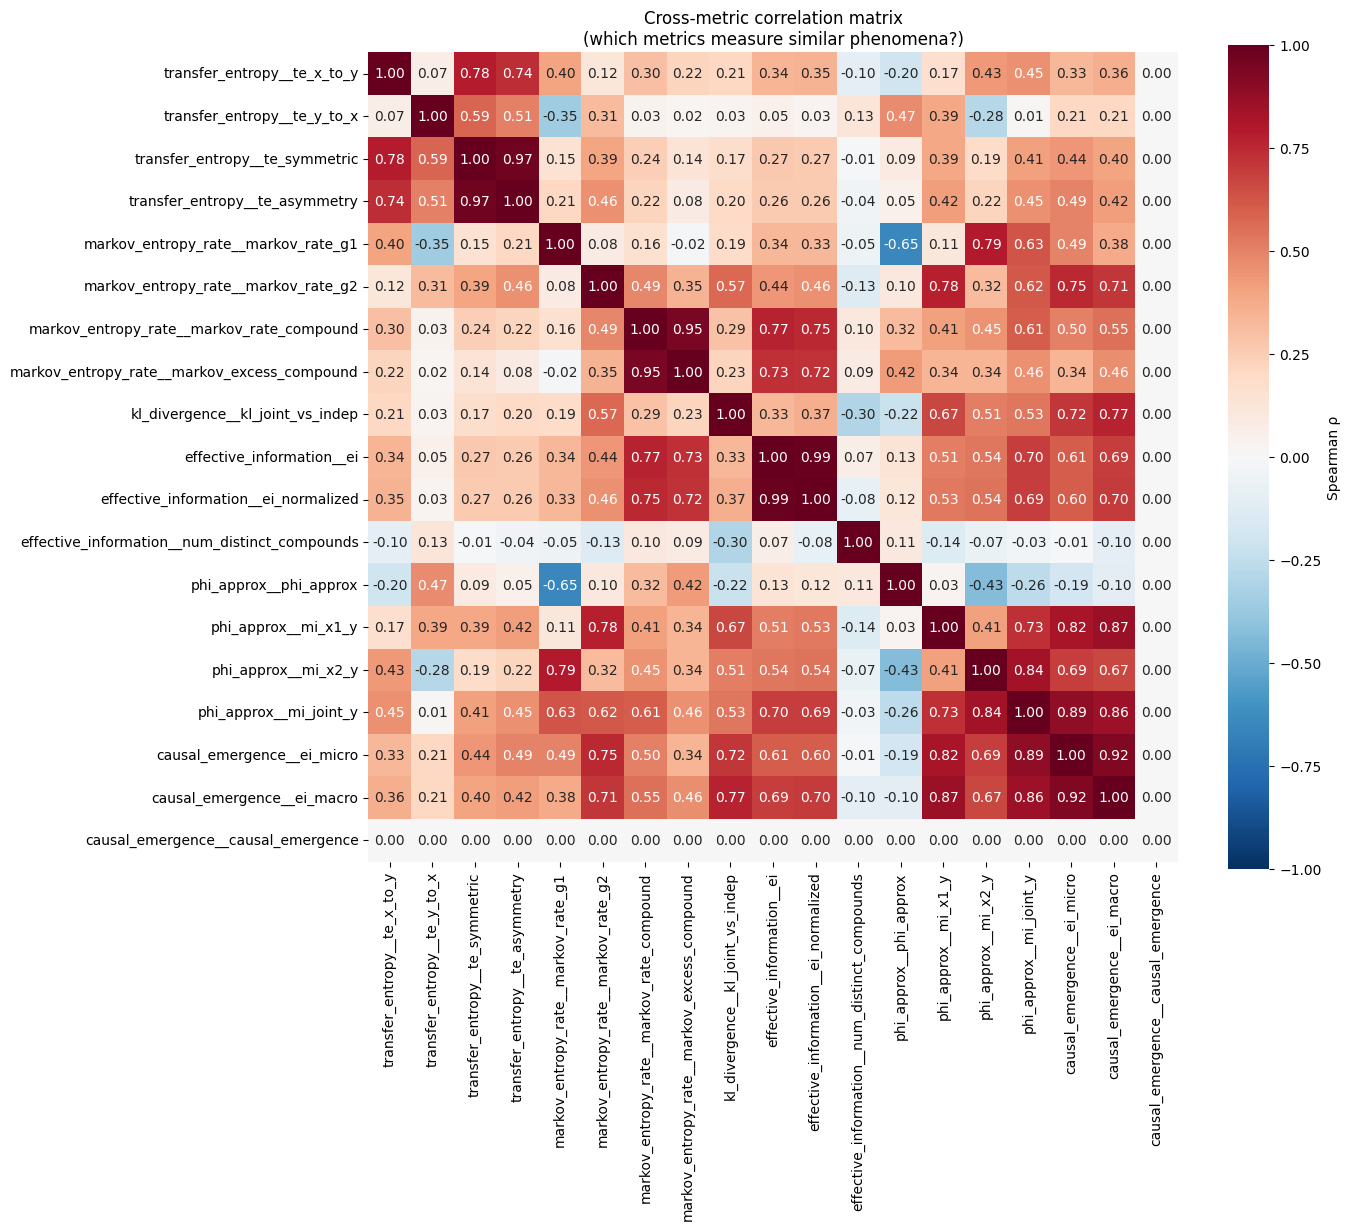

In [8]:
metric_cols = [c for c in df.columns if "__" in c and "error" not in c]
print(f"Metric columns: {len(metric_cols)}")

metric_corr = df[metric_cols].corr(method="spearman")
metric_corr = metric_corr.fillna(0.0)
metric_corr.to_csv(output_dir / "metric_correlations.csv")

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    metric_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Spearman ρ"},
    square=True,
)
ax.set_title("Cross-metric correlation matrix\n(which metrics measure similar phenomena?)")
plt.tight_layout()
plt.savefig(figures_dir / "fig_cross_metric_correlations.pdf", bbox_inches="tight")
plt.show()

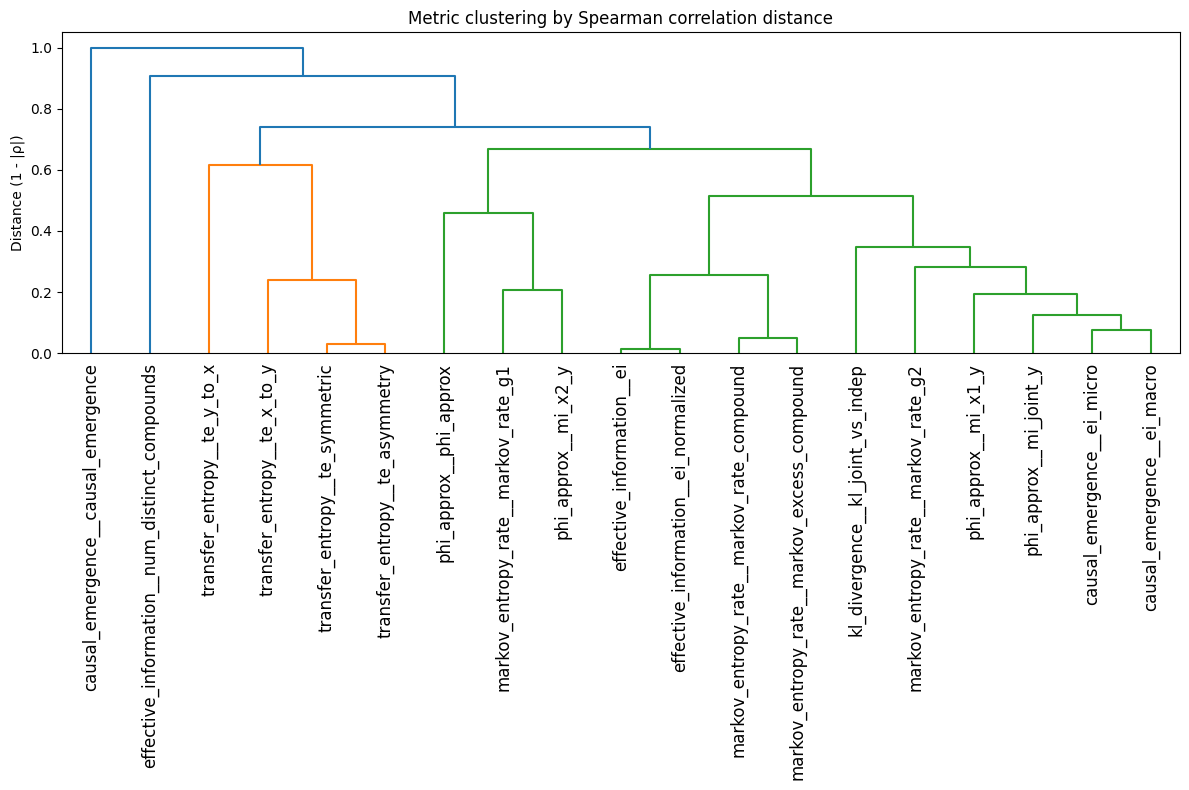

In [9]:
# Writable copy: pandas may expose read-only .values after chained ops (fill_diagonal fails).
_distance = (1 - metric_corr.abs()).to_numpy(dtype=np.float64, copy=True)
np.fill_diagonal(_distance, 0)
condensed = squareform(_distance, checks=False)
Z = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(12, 8))
dendrogram(Z, labels=metric_corr.index.tolist(), ax=ax, leaf_rotation=90)
ax.set_title("Metric clustering by Spearman correlation distance")
ax.set_ylabel("Distance (1 - |ρ|)")
plt.tight_layout()
plt.savefig(figures_dir / "fig_metric_dendrogram.pdf", bbox_inches="tight")
plt.show()

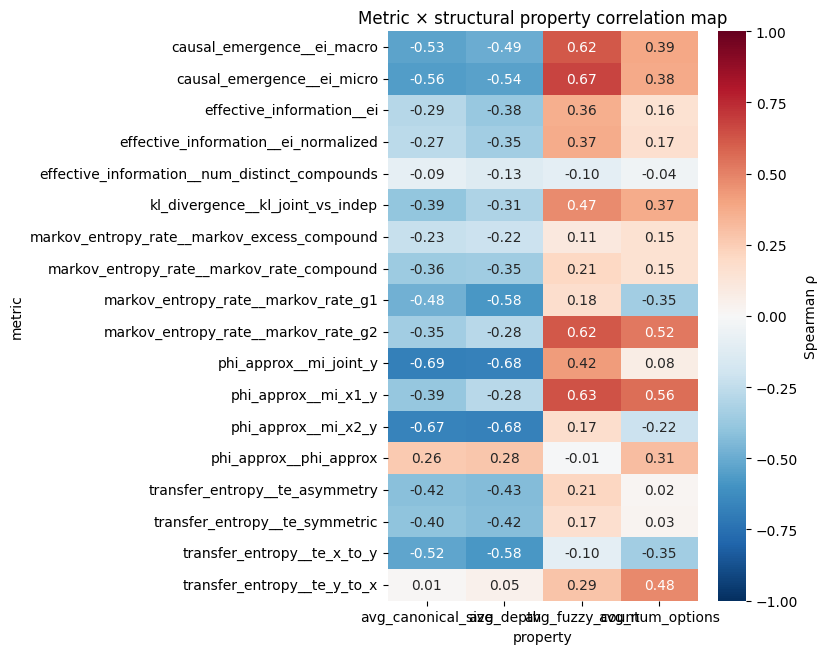

In [10]:
properties = ["avg_depth", "avg_num_options", "avg_fuzzy_count", "avg_canonical_size"]

structural_corr_data = []
for metric in metric_cols:
    if df[metric].nunique() < 2:
        continue
    for prop in properties:
        rho, p = stats.spearmanr(df[prop], df[metric], nan_policy="omit")
        structural_corr_data.append(
            {
                "metric": metric,
                "property": prop,
                "spearman_r": rho if not np.isnan(rho) else 0.0,
                "p_value": p if not np.isnan(p) else 1.0,
            }
        )
struct_corr_df = pd.DataFrame(structural_corr_data)
struct_corr_df.to_csv(output_dir / "structural_correlations.csv", index=False)

pivot = struct_corr_df.pivot(index="metric", columns="property", values="spearman_r")
fig_h = max(6, len(metric_cols) * 0.35)
fig, ax = plt.subplots(figsize=(8, fig_h))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Spearman ρ"},
)
ax.set_title("Metric × structural property correlation map")
plt.tight_layout()
plt.savefig(figures_dir / "fig_metric_property_map.pdf", bbox_inches="tight")
plt.show()

In [11]:
def bootstrap_spearman(x: pd.Series, y: pd.Series, n_boot: int = 500, seed: int = 42):
    rng = np.random.default_rng(seed)
    rhos = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(x), len(x))
        xs = x.iloc[idx]
        ys = y.iloc[idx]
        if xs.nunique() > 1 and ys.nunique() > 1:
            r, _ = stats.spearmanr(xs, ys, nan_policy="omit")
            if not np.isnan(r):
                rhos.append(r)
    if not rhos:
        return np.nan, np.nan
    lo, hi = np.percentile(rhos, [2.5, 97.5])
    return lo, hi


top_corrs = (
    struct_corr_df.assign(abs_r=lambda d: d["spearman_r"].abs())
    .nlargest(10, "abs_r")
    .drop(columns="abs_r")
)

bootstrap_results = []
for _, row in top_corrs.iterrows():
    ci_low, ci_high = bootstrap_spearman(df[row["property"]], df[row["metric"]])
    bootstrap_results.append(
        {
            **row.to_dict(),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "robust": bool(
                not np.isnan(ci_low)
                and not np.isnan(ci_high)
                and abs(ci_low) > 0.3
                and abs(ci_high) > 0.3
                and ci_low * ci_high > 0
            ),
        }
    )
_BOOT_COLS = ["metric", "property", "spearman_r", "p_value", "ci_low", "ci_high", "robust"]
bootstrap_df = (
    pd.DataFrame(bootstrap_results)
    if bootstrap_results
    else pd.DataFrame(columns=_BOOT_COLS)
)
bootstrap_df.to_csv(output_dir / "bootstrap_top_correlations.csv", index=False)
print("Top 10 metric-property correlations with bootstrap CI:")
if len(bootstrap_df) > 0:
    print(
        bootstrap_df[
            ["metric", "property", "spearman_r", "ci_low", "ci_high", "robust"]
        ].to_string(index=False)
    )
else:
    print("(empty — no structural correlations to bootstrap)")

Top 10 metric-property correlations with bootstrap CI:
                             metric           property  spearman_r    ci_low   ci_high  robust
             phi_approx__mi_joint_y avg_canonical_size   -0.687025 -0.825854 -0.474532    True
                phi_approx__mi_x2_y          avg_depth   -0.679190 -0.836474 -0.435813    True
             phi_approx__mi_joint_y          avg_depth   -0.675814 -0.836108 -0.454606    True
         causal_emergence__ei_micro    avg_fuzzy_count    0.674439  0.478996  0.816419    True
                phi_approx__mi_x2_y avg_canonical_size   -0.666978 -0.821483 -0.427324    True
                phi_approx__mi_x1_y    avg_fuzzy_count    0.633158  0.387888  0.791901    True
markov_entropy_rate__markov_rate_g2    avg_fuzzy_count    0.620456  0.418554  0.783300    True
         causal_emergence__ei_macro    avg_fuzzy_count    0.617452  0.389566  0.762142    True
        transfer_entropy__te_x_to_y          avg_depth   -0.584384 -0.744330 -0.405378    

In [12]:
parallel_pairs = df[df["base_class"] == "∥"]
nonparallel_pairs = df[df["base_class"].isin(["L", "R"])]
print(f"∥-pairs: {len(parallel_pairs)}, L/R-pairs: {len(nonparallel_pairs)}")

class_test_results = []
for metric in metric_cols:
    if df[metric].nunique() < 2:
        continue
    if len(parallel_pairs) >= 3 and len(nonparallel_pairs) >= 3:
        _u, p = stats.mannwhitneyu(
            parallel_pairs[metric],
            nonparallel_pairs[metric],
            alternative="greater",
        )
        med_p = parallel_pairs[metric].median()
        med_o = nonparallel_pairs[metric].median()
        class_test_results.append(
            {
                "metric": metric,
                "median_parallel": med_p,
                "median_other": med_o,
                "ratio": med_p / max(1e-9, med_o),
                "mannwhitney_p": p,
            }
        )
_CLASS_COLS = ["metric", "median_parallel", "median_other", "ratio", "mannwhitney_p"]
class_df = (
    pd.DataFrame(class_test_results)
    if class_test_results
    else pd.DataFrame(columns=_CLASS_COLS)
)
class_df.to_csv(output_dir / "class_separation.csv", index=False)
print("Class separation by metric:")
if len(class_df) > 0:
    print(class_df.to_string(index=False))
else:
    print(
        "(empty — need ≥3 ∥-base pairs and ≥3 L/R-base pairs for Mann–Whitney; "
        "pair_limit can drop counts)",
    )

∥-pairs: 0, L/R-pairs: 5
Class separation by metric:
(empty — need ≥3 ∥-base pairs and ≥3 L/R-base pairs for Mann–Whitney; pair_limit can drop counts)


In [13]:
robust_pairs = bootstrap_df[bootstrap_df["robust"]] if len(bootstrap_df) else bootstrap_df
print(f"Robust (metric, property) correlations: {len(robust_pairs)}")

metric_pairs_strong = []
for i, m1 in enumerate(metric_cols):
    for j, m2 in enumerate(metric_cols):
        if i < j and abs(metric_corr.loc[m1, m2]) > 0.6:
            metric_pairs_strong.append((m1, m2, metric_corr.loc[m1, m2]))
print(f"Metric pairs with |ρ| > 0.6: {len(metric_pairs_strong)}")

class_significant = (
    class_df[class_df["mannwhitney_p"] < 0.05]
    if len(class_df) > 0
    else class_df.iloc[0:0]
)
print(f"Metrics with significant ∥ vs L/R separation (p<0.05): {len(class_significant)}")

if len(robust_pairs) >= 1 and (
    len(metric_pairs_strong) >= 1 or len(class_significant) >= 1
):
    verdict = "PASS"
elif len(robust_pairs) >= 1 or len(metric_pairs_strong) >= 2:
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

print("\nExploratory results summary:")
print(f"  Robust metric × property correlations: {len(robust_pairs)}")
print(f"  Strongly clustered metric pairs (|ρ|>0.6): {len(metric_pairs_strong)}")
print(f"  Metrics separating ∥ vs L/R (p<0.05): {len(class_significant)}")
print(f"\nVERDICT: {verdict}")

Robust (metric, property) correlations: 10
Metric pairs with |ρ| > 0.6: 35
Metrics with significant ∥ vs L/R separation (p<0.05): 0

Exploratory results summary:
  Robust metric × property correlations: 10
  Strongly clustered metric pairs (|ρ|>0.6): 35
  Metrics separating ∥ vs L/R (p<0.05): 0

VERDICT: PASS
